In [1]:
from pathlib import Path

# Option 1: Adult Tooth Segmentation
DATASET_ROOT_PATH = r'C:\Users\bacus\Downloads\Dental_dataset\Adult tooth segmentation dataset\Dataset and code'

# Training Configuration
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 10
MODEL_NAME = 'adult_tooth_unet'

In [2]:
!pip install tensorflow opencv-python pillow matplotlib scikit-learn albumentations


In [3]:
import tensorflow as tf
import numpy as np
import cv2
import os
import albumentations as A
from albumentations.core.composition import Compose
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '1'

# GPU setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

In [4]:
train_transforms = Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
])

val_transforms = Compose([])  # no augmentation for validation

In [5]:
def load_image(img_path, mask_path, img_size, transforms=None):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 127).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)

    if transforms:
        augmented = transforms(image=img, mask=mask)
        img = augmented['image']
        mask = augmented['mask']

    img = img.astype(np.float32) / 255.0
    return img, mask

def create_dataset(image_dir, mask_dir, img_size, batch_size, transforms=None):
    image_files = sorted([f for f in Path(image_dir).glob('*.*') 
                         if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']])
    images, masks = [], []
    for idx, img_path in enumerate(image_files):
        # find corresponding mask
        mask_path = next((Path(mask_dir)/f"{img_path.stem}{ext}" for ext in ['.png', '.jpg', '.jpeg', '.bmp'] if (Path(mask_dir)/f"{img_path.stem}{ext}").exists()), None)
        if mask_path is None:
            continue
        img, mask = load_image(img_path, mask_path, img_size, transforms)
        images.append(img)
        masks.append(mask)
    images = np.array(images)
    masks = np.array(masks)
    dataset = tf.data.Dataset.from_tensor_slices((images, masks))
    dataset = dataset.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset, len(images)

In [6]:
dataset_root = Path(DATASET_ROOT_PATH)
train_folder = dataset_root / 'train'
test_folder = dataset_root / 'test'

train_images = train_folder / 'images'
train_masks = train_folder / 'masks'
test_images = test_folder / 'images'
test_masks = test_folder / 'masks'

train_dataset, train_count = create_dataset(train_images, train_masks, IMG_SIZE, BATCH_SIZE, transforms=train_transforms)
val_dataset, val_count = create_dataset(test_images, test_masks, IMG_SIZE, BATCH_SIZE, transforms=val_transforms)

print(f"Training samples: {train_count}, Validation samples: {val_count}")

Training samples: 1500, Validation samples: 478


In [7]:
def conv_block(inputs, filters):
    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    return x

def encoder_block(inputs, filters):
    x = conv_block(inputs, filters)
    p = tf.keras.layers.MaxPooling2D((2,2))(x)
    return x, p

def decoder_block(inputs, skip, filters):
    x = tf.keras.layers.Conv2DTranspose(filters, (2,2), strides=2, padding='same')(inputs)
    x = tf.keras.layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = tf.keras.Input(shape=input_shape)
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)
    b1 = conv_block(p4, 1024)
    b1 = Dropout(0.3)(b1)  # dropout in bridge

    d1 = decoder_block(b1, s4, 512)
    d1 = Dropout(0.2)(d1)
    d2 = decoder_block(d1, s3, 256)
    d2 = Dropout(0.2)(d2)
    d3 = decoder_block(d2, s2, 128)
    d3 = Dropout(0.2)(d3)
    d4 = decoder_block(d3, s1, 64)

    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid', padding='same')(d4)
    return tf.keras.Model(inputs, outputs, name='U-Net')

model = build_unet()
model.summary()


Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [8]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=['accuracy', dice_coefficient, tf.keras.metrics.MeanIoU(num_classes=2)]
)

In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger, TensorBoard
from datetime import datetime

output_dir = Path(f'trained_models/{MODEL_NAME}')
output_dir.mkdir(parents=True, exist_ok=True)

callbacks = [
    ModelCheckpoint(str(output_dir / 'best_model.h5'), monitor='val_dice_coefficient', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_dice_coefficient', patience=10, mode='max', restore_best_weights=True, verbose=1),  # Added mode='max'
    ReduceLROnPlateau(monitor='val_dice_coefficient', factor=0.5, patience=5, mode='max', min_lr=1e-7, verbose=1),  # Added mode='max' here too
    CSVLogger(str(output_dir / 'training_log.csv')),
    TensorBoard(log_dir=str(output_dir / 'logs'), histogram_freq=1)
]

In [10]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8525 - dice_coefficient: 0.6145 - loss: 0.7419 - mean_io_u: 0.4062
Epoch 1: val_dice_coefficient improved from None to 0.10400, saving model to trained_models\adult_tooth_unet\best_model.h5


188/188 ━━━━━━━━━━━━━━━━━━━━ 1885s 10s/step - accuracy: 0.9185 - dice_coefficient: 0.7186 - loss: 0.5139 - mean_io_u: 0.4137 - val_accuracy: 0.7921 - val_dice_coefficient: 0.1040 - val_loss: 1.5076 - val_mean_io_u: 0.3961 - learning_rate: 1.0000e-04
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9508 - dice_coefficient: 0.8086 - loss: 0.3354 - mean_io_u: 0.4168
Epoch 2: val_dice_coefficient improved from 0.10400 to 0.10972, saving model to trained_models\adult_tooth_unet\best_model.h5


188/188 ━━━━━━━━━━━━━━━━━━━━ 1913s 10s/step - accuracy: 0.9525 - dice_coefficient: 0.8155 - loss: 0.3216 - mean_io_u: 0.4171 - val_accuracy: 0.7975 - val_dice_coefficient: 0.1097 - val_loss: 1.5919 - val_mean_io_u: 0.3961 - learning_rate: 1.0000e-04
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9558 - dice_coefficient: 0.8352 - loss: 0.2878 - mean_io_u: 0.4129
Epoch 3: val_dice_coefficient improved from 0.10972 to 0.83252, saving model to trained_models\adult_tooth_unet\best_model.h5


188/188 ━━━━━━━━━━━━━━━━━━━━ 1869s 10s/step - accuracy: 0.9564 - dice_coefficient: 0.8400 - loss: 0.2806 - mean_io_u: 0.4110 - val_accuracy: 0.9409 - val_dice_coefficient: 0.8325 - val_loss: 0.3309 - val_mean_io_u: 0.4038 - learning_rate: 1.0000e-04
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9585 - dice_coefficient: 0.8529 - loss: 0.2594 - mean_io_u: 0.4077
Epoch 4: val_dice_coefficient improved from 0.83252 to 0.85294, saving model to trained_models\adult_tooth_unet\best_model.h5


188/188 ━━━━━━━━━━━━━━━━━━━━ 1893s 10s/step - accuracy: 0.9586 - dice_coefficient: 0.8551 - loss: 0.2568 - mean_io_u: 0.4062 - val_accuracy: 0.9498 - val_dice_coefficient: 0.8529 - val_loss: 0.2769 - val_mean_io_u: 0.3991 - learning_rate: 1.0000e-04
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9606 - dice_coefficient: 0.8640 - loss: 0.2406 - mean_io_u: 0.4050
Epoch 5: val_dice_coefficient improved from 0.85294 to 0.86367, saving model to trained_models\adult_tooth_unet\best_model.h5


188/188 ━━━━━━━━━━━━━━━━━━━━ 1893s 10s/step - accuracy: 0.9605 - dice_coefficient: 0.8663 - loss: 0.2384 - mean_io_u: 0.4033 - val_accuracy: 0.9500 - val_dice_coefficient: 0.8637 - val_loss: 0.2730 - val_mean_io_u: 0.4189 - learning_rate: 1.0000e-04
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9621 - dice_coefficient: 0.8724 - loss: 0.2270 - mean_io_u: 0.4040
Epoch 6: val_dice_coefficient improved from 0.86367 to 0.86727, saving model to trained_models\adult_tooth_unet\best_model.h5


188/188 ━━━━━━━━━━━━━━━━━━━━ 1894s 10s/step - accuracy: 0.9621 - dice_coefficient: 0.8751 - loss: 0.2243 - mean_io_u: 0.4018 - val_accuracy: 0.9524 - val_dice_coefficient: 0.8673 - val_loss: 0.2590 - val_mean_io_u: 0.3989 - learning_rate: 1.0000e-04
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9630 - dice_coefficient: 0.8786 - loss: 0.2180 - mean_io_u: 0.4026
Epoch 7: val_dice_coefficient improved from 0.86727 to 0.87579, saving model to trained_models\adult_tooth_unet\best_model.h5


188/188 ━━━━━━━━━━━━━━━━━━━━ 1931s 10s/step - accuracy: 0.9633 - dice_coefficient: 0.8815 - loss: 0.2139 - mean_io_u: 0.4008 - val_accuracy: 0.9547 - val_dice_coefficient: 0.8758 - val_loss: 0.2376 - val_mean_io_u: 0.3962 - learning_rate: 1.0000e-04
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9646 - dice_coefficient: 0.8864 - loss: 0.2053 - mean_io_u: 0.4008 
Epoch 8: val_dice_coefficient did not improve from 0.87579
188/188 ━━━━━━━━━━━━━━━━━━━━ 2149s 11s/step - accuracy: 0.9646 - dice_coefficient: 0.8872 - loss: 0.2044 - mean_io_u: 0.4005 - val_accuracy: 0.9515 - val_dice_coefficient: 0.8751 - val_loss: 0.2577 - val_mean_io_u: 0.3979 - learning_rate: 1.0000e-04
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9655 - dice_coefficient: 0.8909 - loss: 0.1976 - mean_io_u: 0.4008 
Epoch 9: val_dice_coefficient did not improve from 0.87579
188/188 ━━━━━━━━━━━━━━━━━━━━ 2223s 12s/step - accuracy: 0.9657 - dice_coefficient: 0.8920 - loss: 0.1962 - mean_io

188/188 ━━━━━━━━━━━━━━━━━━━━ 2023s 11s/step - accuracy: 0.9671 - dice_coefficient: 0.8973 - loss: 0.1869 - mean_io_u: 0.4005 - val_accuracy: 0.9522 - val_dice_coefficient: 0.8762 - val_loss: 0.2518 - val_mean_io_u: 0.3961 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 10.


In [11]:
import tensorflow as tf

best_model = tf.keras.models.load_model(
    str(output_dir / 'best_model.h5'),
    custom_objects={'combined_loss': combined_loss, 'dice_coefficient': dice_coefficient}
)

results = best_model.evaluate(val_dataset, verbose=1)
print(f"Loss: {results[0]:.4f}, Accuracy: {results[1]:.4f}, Dice: {results[2]:.4f}, IoU: {results[3]:.4f}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.9522 - dice_coefficient: 0.8762 - loss: 0.2518 - mean_io_u: 0.3961
Loss: 0.2518, Accuracy: 0.9522, Dice: 0.8762, IoU: 0.3961


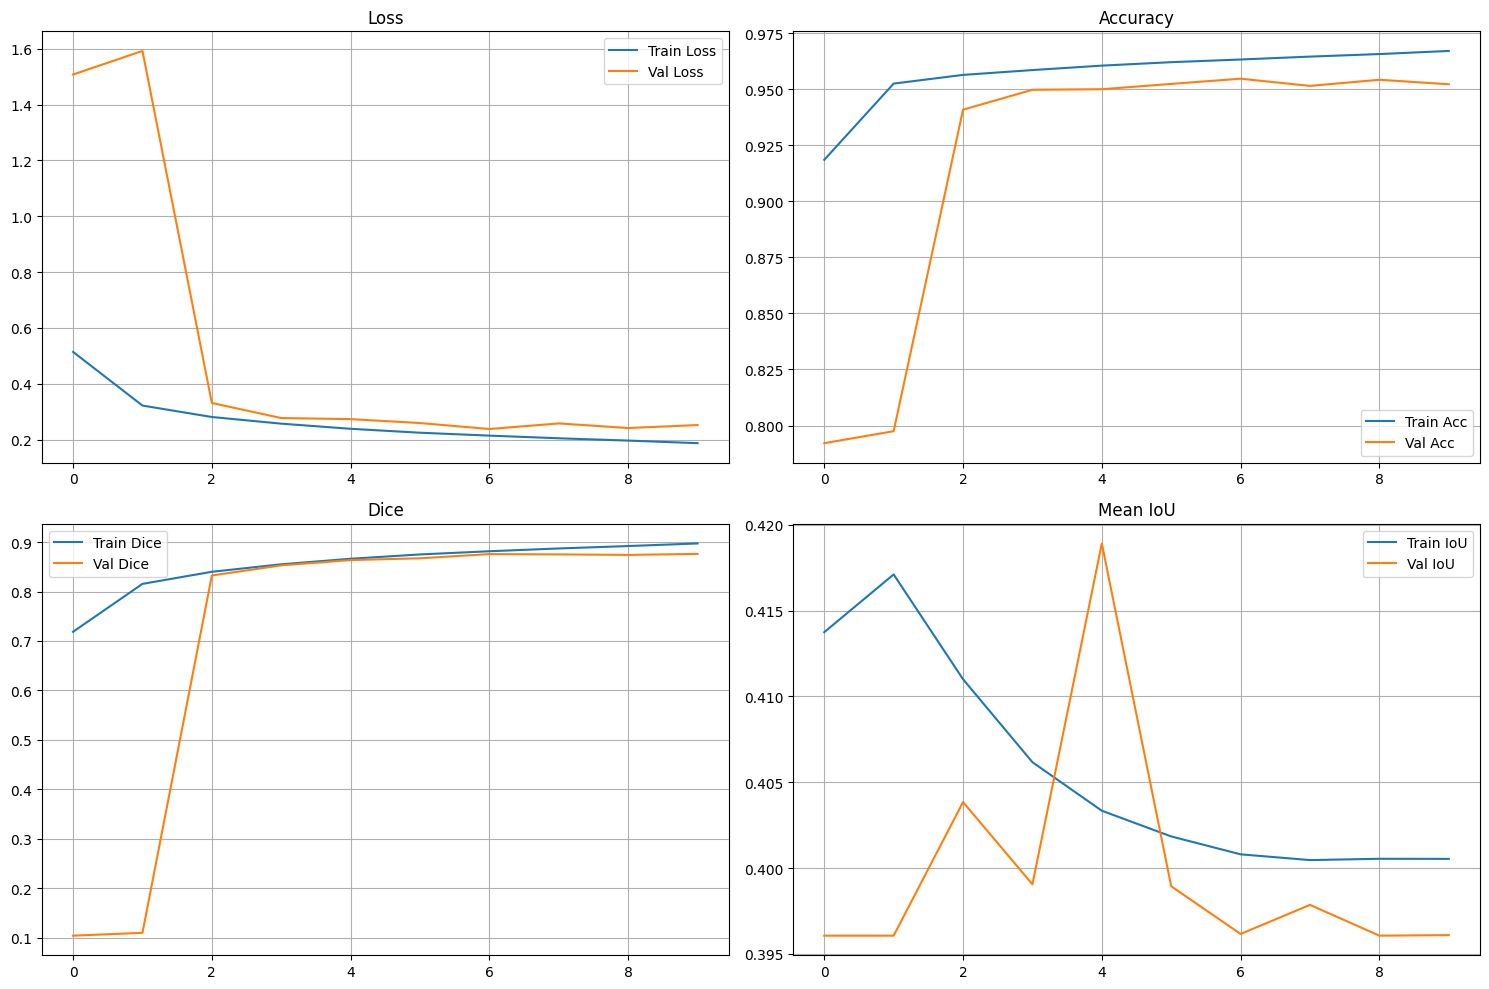

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15,10))

# Loss
axes[0,0].plot(history.history['loss'], label='Train Loss')
axes[0,0].plot(history.history['val_loss'], label='Val Loss')
axes[0,0].set_title('Loss'); axes[0,0].legend(); axes[0,0].grid(True)

# Accuracy
axes[0,1].plot(history.history['accuracy'], label='Train Acc')
axes[0,1].plot(history.history['val_accuracy'], label='Val Acc')
axes[0,1].set_title('Accuracy'); axes[0,1].legend(); axes[0,1].grid(True)

# Dice
axes[1,0].plot(history.history['dice_coefficient'], label='Train Dice')
axes[1,0].plot(history.history['val_dice_coefficient'], label='Val Dice')
axes[1,0].set_title('Dice'); axes[1,0].legend(); axes[1,0].grid(True)

# Mean IoU
axes[1,1].plot(history.history['mean_io_u'], label='Train IoU')
axes[1,1].plot(history.history['val_mean_io_u'], label='Val IoU')
axes[1,1].set_title('Mean IoU'); axes[1,1].legend(); axes[1,1].grid(True)

plt.tight_layout()
plt.show()
